In [ ]:
#########################################################################
# # ! Moon Topographic-Gravitational-Potential Computation: PH vs SH
#########################################################################
# %% 
# # ! Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyshtools as pysh
import pyvista as pv
import time
from datetime import datetime
from gravity_forward_numba import *

In [ ]:
# # ! Start time
print("=" * 80)
print(f"Start time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

Start time: [2026-05-19 21:05:50]


In [ ]:
# # ! Functions
def Shgrid2Mesh(shgrid):
    mesh = pv.Sphere(radius=1.0, center=(0.0, 0.0, 0.0),
                     theta_resolution=shgrid.nlon-1,
                     phi_resolution=shgrid.nlat)
    [LON, LAT] = np.meshgrid(shgrid.lons(), shgrid.lats())
    R = shgrid.data
    X = R * np.cos(np.deg2rad(LAT)) * np.cos(np.deg2rad(LON))
    Y = R * np.cos(np.deg2rad(LAT)) * np.sin(np.deg2rad(LON))
    Z = R * np.sin(np.deg2rad(LAT))
    # north pole, south pole, and regular points
    pts_x = np.hstack([X[0,0], X[-1,0], X[1:-1,:-1].flatten(order='F')]) 
    pts_y = np.hstack([Y[0,0], Y[-1,0], Y[1:-1,:-1].flatten(order='F')])
    pts_z = np.hstack([Z[0,0], Z[-1,0], Z[1:-1,:-1].flatten(order='F')])
    pts_r = np.sqrt(pts_x**2 + pts_y**2 + pts_z**2)
    Verts = np.column_stack((pts_x, pts_y, pts_z))
    mesh.points = Verts
    return mesh, pts_r

In [ ]:
# # ! Load Top-N largest |gD| errors
df_errors = pd.read_csv('output/Moon_gD_errors.csv')
err_lat = df_errors['Lat_deg'].values
err_lon = df_errors['Lon_deg'].values
err_lat_rad = np.deg2rad(err_lat)
err_lon_rad = np.deg2rad(err_lon)
gD_SH = df_errors['gD_SH'].values
df_SH_PHs = df_errors[['Lat_deg', 'Lon_deg', 'Topo_m', 'gD_SH']].copy()

In [ ]:
# # ! Computation of TGP: Polyhedron
#### * Shape of Moon
lmax_shp = 359
clm_shp_moon = \
    pysh.SHCoeffs.from_file(f'input/Moon_shape_719.sh', 
                            lmax=lmax_shp, 
                            name='LOLA_shape (Moon)',
                            units='m', format='bshc')
r_itfc_km = clm_shp_moon.coeffs[0,0,0] / 1.e3
#### * Calculation points
rho0 = 2560.0 # kg/m^3
r_calc_km = 1748000.0 / 1.e3
xps = r_calc_km * np.cos(err_lat_rad) * np.cos(err_lon_rad)
yps = r_calc_km * np.cos(err_lat_rad) * np.sin(err_lon_rad)
zps = r_calc_km * np.sin(err_lat_rad)
#### * Computation of TGP
IN_RES = np.array([15.0, 10.0, 6.0, 5.0, 4.0, 3.0, 2.0, 1.0]) / 60.0 # degree
for in_res in IN_RES:
    nc_Topo = f'output/moon_topo_Lshp{lmax_shp}_{int(60*in_res)}arcmin.nc'
    grd_topo_moon = pysh.SHGrid.from_netcdf(nc_Topo)
    grd_shp_moon = grd_topo_moon + r_itfc_km
    mesh_shp_moon, _ = Shgrid2Mesh(grd_shp_moon)
    mesh_shp_moon
    Verts = mesh_shp_moon.points
    Faces = mesh_shp_moon.regular_faces
    del mesh_shp_moon
    P = np.column_stack((xps, yps, zps))
    t0 = time.time()
    vgt_PH = WerSch_numba_v2(P, Verts, Faces, rho0)
    tc = time.time() - t0
    print("Computation info: \n"
         f"Number of computation points: {P.shape[0]} \n"
         "Polyhedron geometry: \n"
         f"Input resolution: {int(60*in_res):2d}-arcmin \n"
         f"Number of faces: {Faces.shape[0]} \n"
         f"Number of vertices: {Verts.shape[0]} \n"
         f"Time cost : {tc:8.3f} sec = {tc/60:.3f} min = {tc/(60*60):.3f} hr\n")
    #### * TGP = Shape model gravity - Sphere (r=r_itfc) gravity
    vgt_SP = gsphere(xps, yps, zps, 0, 0, 0, r_itfc_km, rho0)
    vgt_TP = tuple(g_PH - g_SP for g_PH, g_SP in zip(vgt_PH, vgt_SP))
    V, gx, gy, gz, Txx, Txy, Txz, Tyy, Tyz, Tzz = vgt_TP
    gN, gE, gD, TNN, TNE, TND, TEE, TED, TDD = \
        rotate_vec_ten_ecef2ned(err_lon_rad, err_lat_rad, 
                                gx, gy, gz, 
                                Txx, Txy, Txz, Tyy, Tyz, Tzz)
    df_SH_PHs[f'gD_PH_{int(60*in_res)}'] = np.round(gD, 4)
    df_SH_PHs[f'e_gD_PH_{int(60*in_res)}'] = np.round(gD - gD_SH, 4)

Computation info: 
Number of computation points: 10 
Polyhedron geometry: 
Input resolution: 15-arcmin 
Number of faces: 2070720 
Number of vertices: 1035362 
Time cost :    1.394 sec = 0.023 min = 0.000 hr

Computation info: 
Number of computation points: 10 
Polyhedron geometry: 
Input resolution: 10-arcmin 
Number of faces: 4661280 
Number of vertices: 2330642 
Time cost :    0.370 sec = 0.006 min = 0.000 hr

Computation info: 
Number of computation points: 10 
Polyhedron geometry: 
Input resolution:  6-arcmin 
Number of faces: 12952800 
Number of vertices: 6476402 
Time cost :    0.984 sec = 0.016 min = 0.000 hr

Computation info: 
Number of computation points: 10 
Polyhedron geometry: 
Input resolution:  5-arcmin 
Number of faces: 18653760 
Number of vertices: 9326882 
Time cost :    1.499 sec = 0.025 min = 0.000 hr

Computation info: 
Number of computation points: 10 
Polyhedron geometry: 
Input resolution:  4-arcmin 
Number of faces: 29149200 
Number of vertices: 14574602 
Time 

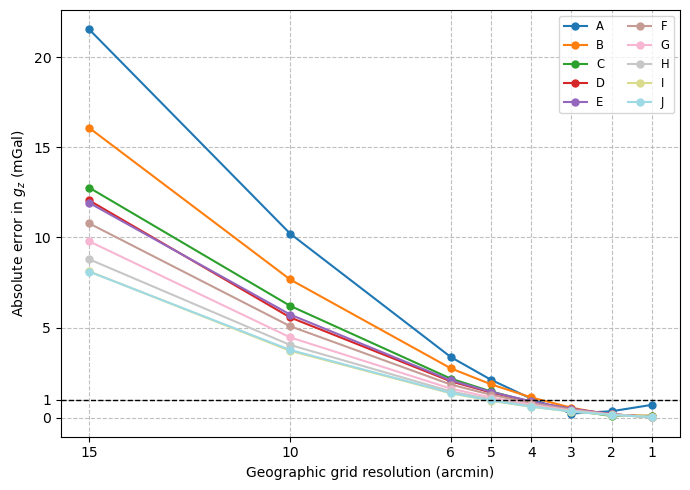

In [ ]:
# # ! Plot error reduction vs. resolution
RES_ARCMIN = sorted([int(60 * in_res) for in_res in IN_RES])
error_cols = [f'e_gD_PH_{res}' for res in RES_ARCMIN]
errors_abs = df_SH_PHs[error_cols].abs()
nP = len(df_SH_PHs)
plt.figure(figsize=(7, 5))
colors = plt.cm.tab20(np.linspace(0, 1, min(nP, 20)))
err_txt = ['A','B','C','D','E','F','G','H','I','J']
for i in range(nP):
    color = colors[i % len(colors)]
    plt.plot(RES_ARCMIN[::-1], errors_abs.iloc[i].values[::-1], 
             marker='o', ms=5, color=color, label=f'{err_txt[i]}')
plt.xlabel('Geographic grid resolution (arcmin)')
plt.ylabel('Absolute error in $g_z$ (mGal)')
plt.xticks(RES_ARCMIN[::-1])
plt.yticks([0, 1, 5, 10, 15, 20])
plt.gca().invert_xaxis()
plt.axhline(y=1, color='black', linestyle='--', linewidth=1.0, alpha=1.0)
plt.grid(which='both', linestyle='--', alpha=0.8)
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()

In [ ]:
print(errors_abs)

   e_gD_PH_1  e_gD_PH_2  e_gD_PH_3  e_gD_PH_4  e_gD_PH_5  e_gD_PH_6  \
0     0.7117     0.3574     0.2317     1.0543     2.0988     3.3588   
1     0.1018     0.1437     0.5520     1.1217     1.8505     2.7345   
2     0.1035     0.0923     0.4180     0.8731     1.4548     2.1642   
3     0.0271     0.1985     0.4837     0.8820     1.3923     2.0135   
4     0.0197     0.1971     0.4921     0.9036     1.4302     2.0702   
5     0.0316     0.1871     0.4458     0.8072     1.2705     1.8347   
6     0.0366     0.1722     0.3979     0.7134     1.1181     1.6113   
7     0.0325     0.1552     0.3596     0.6452     1.0115     1.4579   
8     0.0375     0.1507     0.3392     0.6024     0.9399     1.3508   
9     0.0370     0.1525     0.3446     0.6127     0.9560     1.3737   

   e_gD_PH_10  e_gD_PH_15  
0     10.2084     21.5349  
1      7.6657     16.0735  
2      6.2025     12.7577  
3      5.5610     12.0518  
4      5.7205     11.9144  
5      5.0740     10.7758  
6      4.4546      9.7